__Overall Structure__

Model.py - Define PINN class:
- super init
- forward
- BC + IC + PINN loss = Total Loss

Data.py - Construct Training Points:
- BC's need points with x coordinates -1 or 1, any t value, producing y values of zero
- IC's need points with any x coordinates between [-1,1], t = 0, producing y values of sin(pi*x)
- Collocation points random x and t coordinates, y values from PDE

Train.py - Train the model using Adam (and optionally LBFGS):
- Define optimiser
- For loop: calculate loss, optimiser.zero_grad(), loss.backward(), optimiser.step()

Evaluate.py - How successful is the model? 
- Exact solution (from known solution to the Diffusion PDE)
- Relative error formula

First Test Experiments (IPYNB file)
- Imports
- Create data points, sanity check them
- Test x values at a fixed time
- Generate Heat Map + show relative error
- How does changing Number of collocation points affect 1.final loss 2.relative error 3. training time?
- Test for the Heat Equation with no source - faster exponential decay
- Experimenting with casual training

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import copy
import time

# Import PINN model and training functions from source
from src.model import PINN
from src.data import (
    generate_boundary_points,
    generate_initial_points,
    generate_collocation_points,
)
from src.train import train_pinn
from src.evaluate import relativeERROR

# Set default data type to float32
torch.set_default_dtype(torch.float)

# PyTorch random number generator
torch.manual_seed(1234)

**Heat equation with heat source**

$$\frac{\partial y}{\partial t} =\frac{\partial^2 y}{\partial x^2}-e^{-t}(sin(\pi x)-\pi^2 sin(\pi x))$$

$$x\in[-1,1]$$
$$t\in[0,1]$$

### Initial Condition:

$$y(x,0)=sin(\pi x)$$

### Boundary Conditions:

$$y(-1,t)=0$$
$$y(1,t)=0$$

### Exact solution:

$$y(x,t)=e^{-t}sin(\pi x)$$

In [ ]:
# Generate data points
x_bc, y_bc = generate_boundary_points(100)
def heat_initial_function(x):
    return torch.sin(torch.pi*x)
x_ic, y_ic = generate_initial_points(100, heat_initial_function)
col_points = generate_collocation_points(1000)

torch.Size([100, 2]) torch.Size([100, 1])
torch.Size([100, 2]) torch.Size([100, 1])
torch.Size([1000, 2])
torch.return_types.min(
values=tensor([-1.0000,  0.0065]),
indices=tensor([2, 9]))
torch.return_types.max(
values=tensor([1.0000, 0.9949]),
indices=tensor([ 0, 75]))
torch.float32
torch.float32
torch.float32
torch.float32
torch.float32


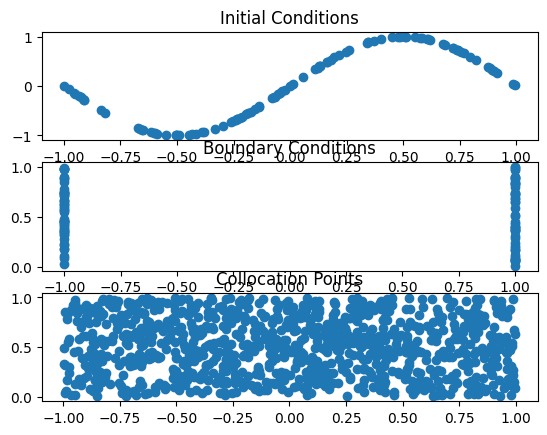

In [3]:
# Sanity Check

#should be (100,2) , (100,1)
print(x_bc.shape, y_bc.shape)
#should be (100,2) , (100,1)
print(x_ic.shape, y_ic.shape)
#should be (n)_col,2)
print(col_points.shape)

#should be between -1 and 1
print(x_bc.min(dim=0))
print(x_bc.max(dim=0))

# Create Scatter Plot
fig, axs = plt.subplots(3)
axs[0].scatter(x_ic[:,[0]],y_ic)
axs[0].set_title('Initial Conditions')
axs[1].scatter(x_bc[:, [0]], x_bc[:, [1]])
axs[1].set_title('Boundary Conditions')
axs[2].scatter(col_points[:,[0]],col_points[:,[1]])
axs[2].set_title('Collocation Points')

# Should all be float32
print(x_bc.dtype)
print(y_bc.dtype)
print(x_ic.dtype)
print(y_ic.dtype)
print(col_points.dtype)

/Users/willcowling/Library/Python/3.9/lib/python/site-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss = float(closure())


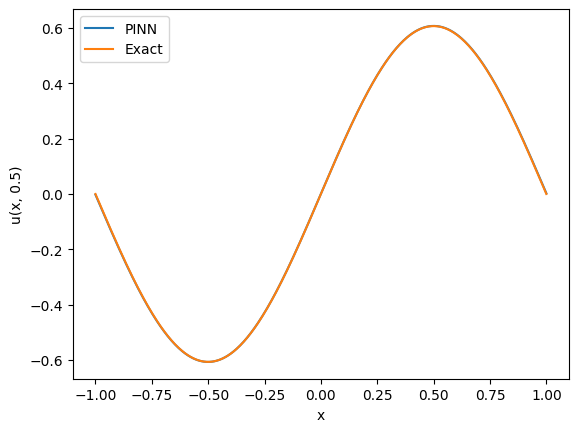

['Iteration 0 | Loss: 16.900858', 'Iteration 1000 | Loss: 0.001684', 'Iteration 2000 | Loss: 0.011047', 'Iteration 3000 | Loss: 0.015267', 'Iteration 4000 | Loss: 0.000138', 'Iteration 5000 | Loss: 0.006335', 'Iteration 6000 | Loss: 0.002984', 'Iteration 7000 | Loss: 0.001031', 'Iteration 8000 | Loss: 0.003401', 'Iteration 9000 | Loss: 0.001414', 'Final Total Loss = 6.487274367827922e-05']
Final Loss over all data points = 6.487274367827922e-05


In [4]:
# At fixed time. At first testing the heat equation without a source
# Create values to test on
x_values = torch.linspace(-1, 1, 500).reshape(-1, 1)
t_values = torch.ones((500, 1)) * 0.5
values = torch.hstack((x_values, t_values))

# Define heat equation with a source term
def heat_equation_heat_source(g, u, derivs):
    x, t = g[:, [0]], g[:, [1]]
    return derivs['u_t'] - derivs['u_xx'] + torch.exp(-t)*(torch.sin(torch.pi*x)-torch.pi**2*torch.sin(torch.pi*x))


def exact_solution_heat_source(x, t):
    return torch.exp(-t) * torch.sin(torch.pi * x)

# Train PINN 
pinn = PINN()
history, final_loss = train_pinn(pinn, x_bc, y_bc, x_ic, y_ic, col_points,
    var_names=['x', 't'],
    PDE_residual_fn=heat_equation_heat_source, epochs = 10000)

# PINN predicted values, using torch.no grad as we are only calling the forward pass
with torch.no_grad():
    predicted_values = pinn(values)

# Exact values using known solution
exact_values = exact_solution_heat_source(x_values, t_values)

# Plot
plt.plot(x_values, predicted_values, label="PINN")
plt.plot(x_values, exact_values, label="Exact")
plt.xlabel("x")
plt.ylabel("u(x, 0.5)")
plt.legend()
plt.show()

# To check that the model is improving after each 1000 epochs
print(history)
print(f'Final Loss over all data points = {final_loss}')

Now for all time values between 0 and 1. Also testing the impact of the LBFGS optimiser on the relative error over all points. Expected to reduce error. Adam does the heavy lifting in finding our local minimum, but starts to struggle as we get close as gradients become very small. LBFGS should get closer, it assesses the full data set, reducing random noise from batches, and uses the second derivative to map the area more accurately. This should help us find the local minimum more accurately. 

In [5]:
# Visualising PINN Prediction over 10000 epochs using heatmap, testing the use of LBFGS optimiser
# Create Grid Points
x = torch.linspace(-1,1,500)
t = torch.linspace(0,1,500)
X, T = torch.meshgrid(x,t, indexing='ij')
grid = torch.hstack((
    X.reshape(-1, 1),
    T.reshape(-1, 1)))

# Create untrained PINN's all using the same inital state
pinn = PINN()
initial_pinn_state = copy.deepcopy(pinn.state_dict())

# Just using Adam to train
pinn_noLBFGS = PINN()
pinn_noLBFGS.load_state_dict(initial_pinn_state)
train_pinn(pinn_noLBFGS,x_bc,y_bc, x_ic, y_ic, col_points, PDE_residual_fn=heat_equation_heat_source, var_names = ['x', 't'], use_LBFGS= False, epochs = 10000)
with torch.no_grad():
    predicted_values_noLBFGS = pinn_noLBFGS(grid)

# Using both Adam and LBFGS to train
pinn_LBFGS = PINN()
pinn_LBFGS.load_state_dict(initial_pinn_state)
train_pinn(pinn_LBFGS,x_bc,y_bc, x_ic, y_ic, col_points, PDE_residual_fn = heat_equation_heat_source, var_names = ['x', 't'], use_LBFGS= True, epochs = 10000)
with torch.no_grad():
    predicted_values_LBFGS = pinn_LBFGS(grid)

# Exact values using known PDE solution
exact_values = exact_solution_heat_source(grid[:,[0]], grid[:,[1]])

print(f"Relative error without LBFGS: {relativeERROR(predicted_values_noLBFGS,exact_values).item():.6f}")
print(f"Relative error using LBFGS: {relativeERROR(predicted_values_LBFGS,exact_values).item():.6f}")
print(history)

Relative error without LBFGS: 0.034291
Relative error using LBFGS: 0.002587
['Iteration 0 | Loss: 16.900858', 'Iteration 1000 | Loss: 0.001684', 'Iteration 2000 | Loss: 0.011047', 'Iteration 3000 | Loss: 0.015267', 'Iteration 4000 | Loss: 0.000138', 'Iteration 5000 | Loss: 0.006335', 'Iteration 6000 | Loss: 0.002984', 'Iteration 7000 | Loss: 0.001031', 'Iteration 8000 | Loss: 0.003401', 'Iteration 9000 | Loss: 0.001414', 'Final Total Loss = 6.487274367827922e-05']


We can see that, as expected, the relative error is much lower after using the LBFGS optimiser at 0.2%, and so I will be using it in this project going forward. 

Text(0, 0.5, 't')

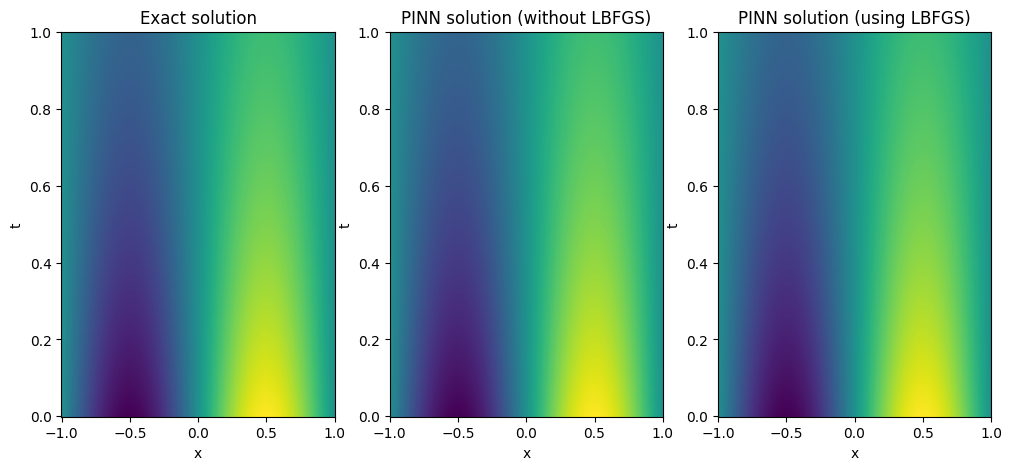

In [ ]:
# Create Heatmap
fig, axs = plt.subplots(1,3, figsize = (12,5))
axs[0].pcolormesh(X,T,exact_values.reshape(X.shape))
axs[0].set_title('Exact solution')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')

axs[1].pcolormesh(X,T,predicted_values_noLBFGS.reshape(X.shape))
axs[1].set_title('PINN solution (without LBFGS)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')

axs[2].pcolormesh(X,T,predicted_values_LBFGS.reshape(X.shape))
axs[2].set_title('PINN solution (using LBFGS)')
axs[2].set_xlabel('x')
axs[2].set_ylabel('t')

Text(0, 0.5, 't')

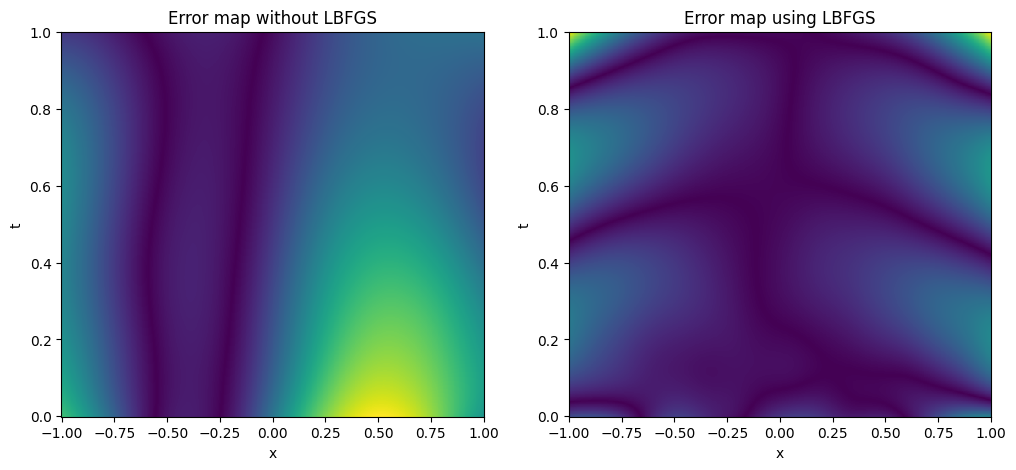

In [ ]:
# Create Error Heatmap Comparing Relative Error with/without LBFGS
fig, axs = plt.subplots(1,2, figsize = (12,5))
axs[0].pcolormesh(X,T,np.abs(predicted_values_noLBFGS-exact_values).reshape(X.shape))
axs[0].set_title('Error map without LBFGS')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')

axs[1].pcolormesh(X,T,np.abs(predicted_values_LBFGS-exact_values).reshape(X.shape))
axs[1].set_title('Error map using LBFGS')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')

Text(0, 0.5, 'Relative Error from exact grid solution')

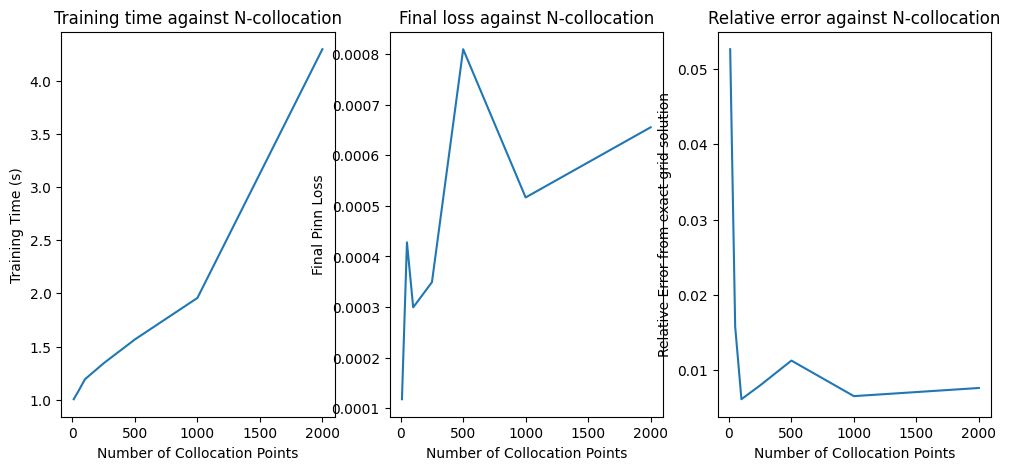

In [14]:
# Investigating how N-collocation affects:  1. training time 2. final loss 3. relative error 

# Experiment Setup
training_time_array = []
final_loss_array = []
relative_error_array = []
pinn = PINN()
initial_pinn_state = copy.deepcopy(pinn.state_dict())

# Exact solution to test against
exact_values = exact_solution_heat_source(grid[:,[0]], grid[:,[1]])

# Train for different numbers of collocation points
N_collocation = [10,50,100,250,500,1000,2000]
for i in N_collocation:
     pinn = PINN()
     pinn.load_state_dict(initial_pinn_state)
     start_time = time.perf_counter()
     history, final_loss = train_pinn(pinn,x_bc,y_bc, x_ic,y_ic,generate_collocation_points(i), PDE_residual_fn = heat_equation_heat_source, var_names = ['x', 't'])
     training_time = time.perf_counter() - start_time
     training_time_array.append(training_time)
     final_loss_array.append(final_loss.item())
     with torch.no_grad():
          predicted_values_LBFGS = pinn(grid)
     relative_error_array.append(relativeERROR(predicted_values_LBFGS,exact_values).item())

# Plotting
fig, axs = plt.subplots(1,3, figsize = (12,5))
axs[0].plot(N_collocation,training_time_array)
axs[0].set_title('Training time against N-collocation')
axs[0].set_xlabel('Number of Collocation Points')
axs[0].set_ylabel('Training Time (s)')
axs[1].plot(N_collocation,final_loss_array)
axs[1].set_title('Final loss against N-collocation')
axs[1].set_xlabel('Number of Collocation Points')
axs[1].set_ylabel('Final Pinn Loss')
axs[2].plot(N_collocation,relative_error_array)
axs[2].set_title('Relative error against N-collocation')
axs[2].set_xlabel('Number of Collocation Points')
axs[2].set_ylabel('Relative Error from exact grid solution')

This suggests that after ~1000 collocation points the model does not seem to significantly improve, despite the training time continuing to increase. Note - the final loss is very low for 10 points, as the model overfits to these points. 